# Machine Translation

This notebook demonstrates the machine translation model using Encoder Decoder Architecture build using GRU Layers as base for Eng-French translation.

## Idea

- To take the english to french corpus
- Use Teacher Forcing while training

    Teacher Forcing Eg:
    ```
    Input to decoder     Target prediction

    <BOS>                Je
    Je                   suis
    suis                 faim
    faim                 <EOS>
    ```
- Encoder example :
    ```
    "I"        "am"        "hungry"
     |           |             |
     v           v             v
    RNN ------> RNN --------> RNN
     h1          h2            h3
                                |
                                v
                          context vector
    ```

In [36]:
# Imports
# ===========

import collections
import sys
import logging
import time
import math
from dataclasses import dataclass
from pathlib import Path
from shutil import copyfileobj
from urllib.parse import urlparse
from urllib.request import Request, urlopen
from zipfile import ZipFile

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

PROJECT_ROOT = Path.cwd().parent if (Path.cwd().parent / "src").is_dir() else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.mt.model import Seq2Seq, Seq2SeqDecoder, Seq2SeqEncoder, Seq2SeqInputs

## Data Preparation

- Downloading the corpus
- Preprocessing the data :
    - Replacing the non breaking space with simple space
    - separating the punctuation marks and space between punctuations and words
- Tokenisation of data
    - Adding `<eos>` char at sentence end for training purposes
    - Making source --> target mappings
    - Adding `<bos>` token in the data

### Problem : 

In general hwenever training the language models I have kept the size of the inputs same throughout the data corpus but right now as we are tokenising the words this can be difficult because right now in the corpus we can have long sentences so what we will do is that we will have `max_sentence_size` and then go with that. If sentence is small we just add `<pad>` token or if sentence is > `max_sentence_size` then we truncate the sentence size. Or we can do bucketting like keep similar-ish sized sentence in different minibatches for training and then train all but If 95 % of sentences are 50 words long then we dont need to worry much about rest 5 % of sentences.

In [16]:
# Data Preparation
# =====================

class Vocab:
    def __init__(self, tokens: list[str] = [], min_freq: int = 0, reserved_tokens:list[str] = []):
        # flatten the token list (if needed)
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(
            counter.items(),
            key = lambda x: x[1], # sort by frequency
            reverse = True
        )
        self.index_to_token = sorted(set(
                ['<unk>'] + 
                reserved_tokens + 
                [
                    token for token, freq in self.token_freqs if freq >= min_freq
                ]
            ))
        self.token_to_index = {
            token: idx for idx, token in enumerate(self.index_to_token)
        }
    
    def __len__(self):
        return len(self.index_to_token)

    def __getitem__(self, tokens: list | tuple):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_index.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices: list[int]):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.index_to_token[int(index)] for index in indices]
        return self.index_to_token[indices]

    @property
    def unk(self):
        return self.token_to_index['<unk>']

@dataclass
class MTDataInput:
    data_url: str
    zip_data: bool
    max_steps: int

@dataclass
class DataLoaderConfig:
    train_percentage: int
    validation_percentage: int
    batch_size: int

class MTData:
    def __init__(self, mt_data_input: MTDataInput):
        self.mt_data_input = mt_data_input

    def _download_and_extract(self) -> Path:
        data_dir = Path("data")
        data_dir.mkdir(parents=True, exist_ok=True)

        file_name = Path(urlparse(self.mt_data_input.data_url).path).name
        if not file_name:
            raise ValueError("data_url must contain a file name")

        file_path = data_dir / file_name
        if not file_path.exists():
            temporary_path = file_path.with_suffix(file_path.suffix + ".part")
            request = Request(
                self.mt_data_input.data_url, headers={"User-Agent": "curl/8.0"}
            )
            with urlopen(request) as response, temporary_path.open("wb") as output:
                copyfileobj(response, output)
            temporary_path.replace(file_path)

        if not self.mt_data_input.zip_data:
            self.file_path = file_path
            return file_path

        extract_dir = file_path.with_suffix("")
        extract_dir.mkdir(exist_ok=True)
        root = extract_dir.resolve()
        with ZipFile(file_path) as archive:
            if any(
                not (root / member.filename).resolve().is_relative_to(root)
                for member in archive.infolist()
            ):
                raise ValueError("Archive contains an unsafe path")
            archive.extractall(extract_dir)
        self.file_path = extract_dir
        return extract_dir

    def read_data(self, file_name: str) -> str:
        return (self.file_path / file_name).read_text(encoding="utf-8")

    def _preprocess(self, text: str) -> str:
        # Replace non-breaking space with space
        text = text.replace('\u202f', ' ').replace('\xa0', ' ')
        # Insert space between words and punctuation marks
        no_space = lambda char, prev_char: char in ',.!?' and prev_char != ' '
        out = []
        for i, char in enumerate(text.lower()):
            if i > 0 and no_space(char, text[i - 1]):
                out.append(' ' + char)
            else:
                out.append(char)
        return "".join(out)

    def _tokenize(self, text: str) -> tuple[list[str], list[str]]:
        pairs = [
            line.split("\t", 2)[:2]
            for line in text.splitlines()
        ]
        src, tgt = [f'{pair[0]} <eos>'.split(' ') for pair in pairs], [f'{pair[1]} <eos>'.split(' ') for pair in pairs]
        return src, tgt

    def build_dataloaders(
        self,
        src: list[list[str]],
        tgt: list[list[str]],
        dataloader_config: DataLoaderConfig,
    ) -> tuple[DataLoader, DataLoader]:
        if len(src) != len(tgt) or not src:
            raise ValueError("Source and target corpora must be non-empty and equal in size")
        if (
            dataloader_config.train_percentage <= 0
            or dataloader_config.validation_percentage <= 0
            or dataloader_config.train_percentage + dataloader_config.validation_percentage != 100
            or dataloader_config.batch_size <= 0
        ):
            raise ValueError("Percentages must be positive and total 100; batch size must be positive")

        def build_data(
            sentences: list[list[str]], vocab: Vocab | None, is_target: bool
        ) -> tuple[torch.Tensor, Vocab, torch.Tensor]:
            if is_target:
                sentences = [["<bos>"] + sentence for sentence in sentences]
            if vocab is None:
                vocab = Vocab(
                    sentences,
                    min_freq=2,
                    reserved_tokens=["<pad>", "<bos>", "<eos>"],
                )
            sentences = [
                sentence[:self.mt_data_input.max_steps]
                + ["<pad>"] * max(0, self.mt_data_input.max_steps - len(sentence))
                for sentence in sentences
            ]
            data = torch.tensor(vocab[sentences], dtype=torch.long)
            valid_lengths = (data != vocab["<pad>"]).to(torch.int32).sum(1)
            return data, vocab, valid_lengths

        indices = torch.randperm(len(src)).tolist()
        train_size = len(src) * dataloader_config.train_percentage // 100
        if train_size == 0 or train_size == len(src):
            raise ValueError("Corpus is too small for the requested split or Not too many validation examples")
        train_indices, validation_indices = indices[:train_size], indices[train_size:]

        def select(sentences: list[list[str]], indices: list[int]) -> list[list[str]]:
            return [sentences[index] for index in indices]

        train_src, self.src_vocab, train_src_lengths = build_data(
            select(src, train_indices), None, False
        )
        train_tgt, self.tgt_vocab, train_tgt_lengths = build_data(
            select(tgt, train_indices), None, True
        )
        validation_src, _, validation_src_lengths = build_data(
            select(src, validation_indices), self.src_vocab, False
        )
        validation_tgt, _, validation_tgt_lengths = build_data(
            select(tgt, validation_indices), self.tgt_vocab, True
        )

        train_data = TensorDataset(
            train_src, train_src_lengths, train_tgt, train_tgt_lengths
        )
        validation_data = TensorDataset(
            validation_src,
            validation_src_lengths,
            validation_tgt,
            validation_tgt_lengths,
        )
        return (
            DataLoader(train_data, dataloader_config.batch_size, shuffle=True),
            DataLoader(validation_data, dataloader_config.batch_size),
        )

DATA_URL = "https://www.manythings.org/anki/fra-eng.zip"
CORPUS_FILE_NAME = "fra.txt"
MAX_STEPS = 20
mt_data_input = MTDataInput(DATA_URL, True, MAX_STEPS)
mt_data = MTData(mt_data_input)
mt_data._download_and_extract()

PosixPath('data/fra-eng')

In [17]:
raw_text = mt_data.read_data(CORPUS_FILE_NAME)
print(raw_text[:150])

Go.	Va !	CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #1158250 (Wittydev)
Go.	Marche.	CC-BY 2.0 (France) Attribution: tatoeba.org #2877


In [18]:
text = mt_data._preprocess(raw_text)
print(text[:150])

go .	va !	cc-by 2 .0 (france) attribution: tatoeba .org #2877272 (cm) & #1158250 (wittydev)
go .	marche .	cc-by 2 .0 (france) attribution: tatoeba .or


In [19]:
src, tgt = mt_data._tokenize(text)
src[:5], tgt[:5]

([['go', '.', '<eos>'],
  ['go', '.', '<eos>'],
  ['go', '.', '<eos>'],
  ['go', '.', '<eos>'],
  ['hi', '.', '<eos>']],
 [['va', '!', '<eos>'],
  ['marche', '.', '<eos>'],
  ['en', 'route', '!', '<eos>'],
  ['bouge', '!', '<eos>'],
  ['salut', '!', '<eos>']])

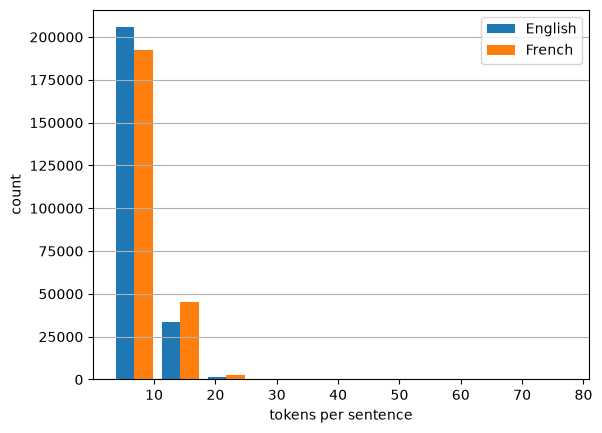

In [20]:
# Let's check if bucketing is worth it for the corpus
# Result : Not worth it as most of sentences will fit in 20 tokens
# as most of the sentences are less than 10 tokens

plt.hist(
    ([len(sentence) for sentence in src], [len(sentence) for sentence in tgt]),
    label=("English", "French"),
)
plt.xlabel("tokens per sentence")
plt.ylabel("count")
plt.legend()
plt.grid(axis="y")
plt.show()

In [21]:
train_percentage = 80
val_percentage = 20
BATCH_SIZE = 256
dataloader_config = DataLoaderConfig(train_percentage, val_percentage, BATCH_SIZE)
train_dataloader, val_dataloader = mt_data.build_dataloaders(src, tgt, dataloader_config)

In [22]:
# Sanity
# Corpus Shape : 
# [
#    (batch_size, max_steps),
#    (batch_size),
#    (batch_size, max_steps),
#    (batch_size)
# ]
for data in train_dataloader:
    print(data[0][0])
    print(data[1])
    print(data[2][0])
    print(data[3])
    break

tensor([ 5022,  1660,   438, 10062,  7288,  9855,   131,   249,   250,   250,
          250,   250,   250,   250,   250,   250,   250,   250,   250,   250])
tensor([ 8,  5,  9, 13,  6,  9,  8, 11,  8,  7, 10,  8,  6,  5,  7,  7,  5,  8,
         5,  8,  9,  9,  7,  9, 10,  5,  8,  7,  6, 18,  9, 10,  9,  5,  8,  4,
         7,  7,  5,  6,  9,  6,  6, 10,  7, 14,  6,  8, 10,  8,  7,  8,  4,  7,
         8,  6, 10,  7,  4, 10, 10,  6,  7,  7,  8,  6, 11, 10,  8,  6,  5, 11,
         6,  7,  9,  5, 10, 15,  5,  9, 11, 13,  6,  5,  4,  9,  9,  9,  6,  9,
         6,  7,  7, 11, 10,  9,  5,  8,  5,  9,  8,  7,  7,  6,  4,  8, 12,  7,
         8, 11,  9,  4,  6,  7,  7,  8, 11,  7,  9, 12,  9,  9,  7,  6,  8,  5,
         6, 11, 14, 11,  9,  9, 10, 11, 20,  8,  9,  9,  4, 10,  7,  7,  6,  9,
         4,  4,  8, 13, 10,  8,  6, 10,  5,  6,  7,  9,  6, 11, 12,  6,  5,  5,
         8,  9,  7,  8, 12,  4,  8,  9,  7,  8,  4,  7, 10,  5,  5,  8, 15,  8,
         5,  8,  7,  9, 13, 10, 13,  8,  8,

In [23]:
# Model init

EMBEDDING_SIZE = 128
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.1
LEARNING_RATE = 1e-3
DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using Device : {DEVICE} for training")

encoder = Seq2SeqEncoder(
    Seq2SeqInputs(len(mt_data.src_vocab), EMBEDDING_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
)
decoder = Seq2SeqDecoder(
    Seq2SeqInputs(len(mt_data.tgt_vocab), EMBEDDING_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
)
model = Seq2Seq(encoder, decoder).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
PAD_INDEX = mt_data.tgt_vocab["<pad>"]
loss_function = torch.nn.CrossEntropyLoss(ignore_index=PAD_INDEX, reduction="sum")

Using Device : mps for training


In [24]:
# Training

logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)
logger = logging.getLogger("machine_translation")

def train(
    model: Seq2Seq,
    train_loader: DataLoader,
    validation_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_function: torch.nn.CrossEntropyLoss,
    epochs: int,
) -> list[tuple[float, float]]:
    model.to(DEVICE)
    history = []

    def show_progress(phase, current, total, loss_sum, tokens, started):
        width = 30
        filled = width * current // total
        bar = "#" * filled + "-" * (width - filled)
        elapsed = max(time.perf_counter() - started, 1e-9)
        print(
            f"\r{phase:<10} [{bar}] {current}/{total} "
            f"loss={loss_sum / max(tokens, 1):.4f} "
            f"tokens/s={tokens / elapsed:,.0f}",
            end="\n" if current == total else "",
            flush=True,
        )

    def batch_loss(batch):
        source, source_lengths, target, _ = (tensor.to(DEVICE) for tensor in batch)
        decoder_input, labels = target[:, :-1], target[:, 1:]
        logits = model(source, decoder_input, source_lengths)
        token_count = (labels != PAD_INDEX).sum()
        loss = loss_function(logits.reshape(-1, logits.shape[-1]), labels.reshape(-1))
        return loss, token_count

    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        model.train()
        train_loss_sum = train_tokens = 0
        for batch_number, batch in enumerate(train_loader, 1):
            optimizer.zero_grad(set_to_none=True)
            loss, token_count = batch_loss(batch)
            (loss / token_count.clamp_min(1)).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss_sum += loss.item()
            train_tokens += token_count.item()
            show_progress(
                "training", batch_number, len(train_loader),
                train_loss_sum, train_tokens, started,
            )
        training_elapsed = time.perf_counter() - started

        model.eval()
        validation_started = time.perf_counter()
        validation_loss_sum = validation_tokens = 0
        with torch.no_grad():
            for batch_number, batch in enumerate(validation_loader, 1):
                loss, token_count = batch_loss(batch)
                validation_loss_sum += loss.item()
                validation_tokens += token_count.item()
                show_progress(
                    "validation", batch_number, len(validation_loader),
                    validation_loss_sum, validation_tokens, validation_started,
                )

        train_loss = train_loss_sum / max(train_tokens, 1)
        validation_loss = validation_loss_sum / max(validation_tokens, 1)
        tokens_per_second = train_tokens / max(training_elapsed, 1e-9)
        history.append((train_loss, validation_loss))
        logger.info(
            "epoch=%d/%d train_loss=%.4f validation_loss=%.4f tokens/s=%.0f elapsed=%.1fs",
            epoch, epochs, train_loss, validation_loss, tokens_per_second,
            time.perf_counter() - started,
        )

    return history

history = train(
    model, train_dataloader, val_dataloader, optimizer, loss_function, epochs=10
)

training   [##############################] 752/752 loss=4.5348 tokens/s=20,437
validation [##############################] 188/188 loss=3.2911 tokens/s=60,929


epoch=1/10 train_loss=4.5348 validation_loss=3.2911 tokens/s=20437 elapsed=86.8s


training   [##############################] 752/752 loss=2.7774 tokens/s=20,775
validation [##############################] 188/188 loss=2.3357 tokens/s=64,095


epoch=2/10 train_loss=2.7774 validation_loss=2.3357 tokens/s=20774 elapsed=85.1s


training   [##############################] 752/752 loss=2.0832 tokens/s=20,538
validation [##############################] 188/188 loss=1.9208 tokens/s=55,742


...

epoch=8/10 train_loss=1.0163 validation_loss=1.3866 tokens/s=20488 elapsed=86.9s


training   [##############################] 752/752 loss=0.9328 tokens/s=18,527
validation [##############################] 188/188 loss=1.3593 tokens/s=60,339


epoch=9/10 train_loss=0.9328 validation_loss=1.3593 tokens/s=18527 elapsed=95.1s


training   [##############################] 752/752 loss=0.8643 tokens/s=20,454
validation [##############################] 188/188 loss=1.3444 tokens/s=62,744


epoch=10/10 train_loss=0.8643 validation_loss=1.3444 tokens/s=20454 elapsed=86.5s


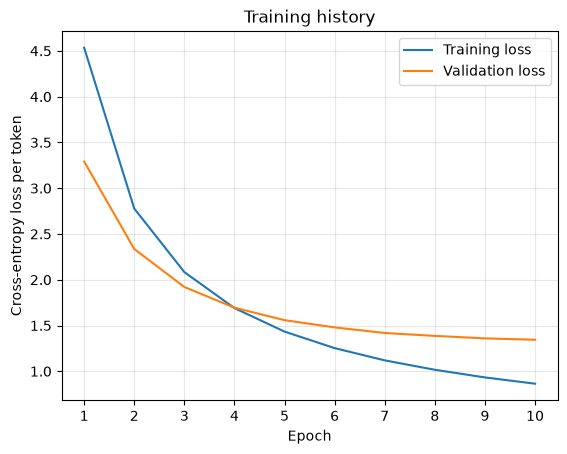

In [25]:
# Training history
train_losses, validation_losses = zip(*history)
epochs = range(1, len(history) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Training loss")
plt.plot(epochs, validation_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss per token")
plt.title("Training history")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [42]:
# Greedy translation
@torch.inference_mode()
def predict(sentence: str, max_steps: int = MAX_STEPS) -> str:
    model.eval()
    device = next(model.parameters()).device
    tokens = mt_data._preprocess(sentence).strip().split() + ["<eos>"]
    valid_length = min(len(tokens), max_steps)
    tokens = tokens[:max_steps] + ["<pad>"] * max(0, max_steps - len(tokens))
    source = torch.tensor([mt_data.src_vocab[tokens]], dtype=torch.long, device=device)
    source_lengths = torch.tensor([valid_length], device=device)
    encoded = model.encoder(source, source_lengths)
    state = model.decoder.init_state(encoded)
    decoder_input = torch.tensor(
        [[mt_data.tgt_vocab["<bos>"]]], dtype=torch.long, device=device
    )

    output_tokens = []
    for _ in range(max_steps):
        logits, state = model.decoder(decoder_input, state)
        next_index = int(logits[:, -1].argmax(dim=-1).item())
        token = mt_data.tgt_vocab.to_tokens(next_index)
        if token == "<eos>":
            break
        if token not in {"<bos>", "<pad>"}:
            output_tokens.append(token)
        decoder_input = torch.tensor([[next_index]], dtype=torch.long, device=device)

    translation = " ".join(output_tokens)
    for punctuation in ",.!?":
        translation = translation.replace(f" {punctuation}", punctuation)
    return translation

sentences = [
    "The house is on the hill.",
    "There is no one there.",
    "I think we should go back."
]
for s in sentences:
    print(predict(s))

la maison est sur la colline.
il n'y a personne.
je pense que nous devrions y retourner.


In [43]:
# Corpus BLEU-4 evaluation with add-one smoothing

def corpus_bleu(references, candidates, max_n: int = 4) -> float:
    matches = [0] * max_n
    totals = [0] * max_n
    reference_length = candidate_length = 0

    for reference, candidate in zip(references, candidates):
        reference_length += len(reference)
        candidate_length += len(candidate)
        for n in range(1, max_n + 1):
            reference_ngrams = collections.Counter(
                tuple(reference[i:i + n]) for i in range(len(reference) - n + 1)
            )
            candidate_ngrams = collections.Counter(
                tuple(candidate[i:i + n]) for i in range(len(candidate) - n + 1)
            )
            matches[n - 1] += sum((reference_ngrams & candidate_ngrams).values())
            totals[n - 1] += sum(candidate_ngrams.values())

    if candidate_length == 0:
        return 0.0
    precisions = [
        (matches[i] + 1) / (totals[i] + 1)
        for i in range(max_n)
        if totals[i] > 0
    ]
    brevity_penalty = math.exp(min(0, 1 - reference_length / candidate_length))
    return 100 * brevity_penalty * math.exp(
        sum(math.log(precision) for precision in precisions) / len(precisions)
    )

@torch.inference_mode()
def evaluate_bleu(model: Seq2Seq, loader: DataLoader) -> float:
    model.eval()
    device = next(model.parameters()).device
    bos_index = mt_data.tgt_vocab["<bos>"]
    eos_index = mt_data.tgt_vocab["<eos>"]
    special_indices = {bos_index, eos_index, PAD_INDEX}
    references, candidates = [], []

    for source, source_lengths, target, _ in loader:
        source = source.to(device)
        source_lengths = source_lengths.to(device)
        encoded = model.encoder(source, source_lengths)
        state = model.decoder.init_state(encoded)
        decoder_input = torch.full(
            (source.shape[0], 1), bos_index, dtype=torch.long, device=device
        )
        batch_candidates = [[] for _ in range(source.shape[0])]
        finished = [False] * source.shape[0]

        for _ in range(MAX_STEPS):
            logits, state = model.decoder(decoder_input, state)
            next_indices = logits[:, -1].argmax(dim=-1)
            for i, index in enumerate(next_indices.tolist()):
                if not finished[i]:
                    if index == eos_index:
                        finished[i] = True
                    elif index not in special_indices:
                        batch_candidates[i].append(index)
            if all(finished):
                break
            decoder_input = next_indices.unsqueeze(1)

        candidates.extend(batch_candidates)
        for row in target.tolist():
            reference = []
            for index in row:
                if index == eos_index:
                    break
                if index not in special_indices:
                    reference.append(index)
            references.append(reference)

    return corpus_bleu(references, candidates)

bleu_score = evaluate_bleu(model, val_dataloader)
print(f"Validation BLEU-4: {bleu_score:.2f}")

Validation BLEU-4: 32.80
